## Dataset Information

#### Context
- This dataset contains detailed information about residential properties available for rent in major Indian cities. It captures key   features of rental listings, including property type, location, size, amenities, and rental price. This data is suitable for analyzing rental market trends, predicting rental prices, and understanding the distribution of residential properties across different urban areas in India.

#### Content
- The dataset comprises 7,691 records and 10 columns. Each row represents a unique rental listing.

#### Columns:

- house_type (String): A descriptive title of the listing, often including the configuration (e.g., "2 BHK Flat"), property type (Flat/House), project name, and location.
- locality (String): The specific neighborhood or area within the city where the property is located (e.g., "Goregaon East", "Whitefield").
- city (String): The city where the property is situated. The dataset covers the following cities:
1. New Delhi
2. Bangalore
3. Pune
4. Mumbai
5. Nagpur
- area (Float): The size of the property in square feet (sq. ft.).
- Range: 2 sq. ft. to 70,000 sq. ft. (Note: The minimum value of 2 might indicate data entry errors or specific non-standard units).
- beds (Integer): The number of bedrooms in the property.
- Range: 1 to 10 bedrooms.
- bathrooms (Integer): The number of bathrooms available.
- Range: 0 to 10 bathrooms.
- balconies (Integer): The number of balconies in the property.
- Range: 0 to 10 balconies.
- furnishing (String): The furnishing status of the property. Categories include:
- Semi-Furnished
- Unfurnished
- Furnished
- area_rate (Float): The calculated rental rate per square foot (likely rent / area).
- rent (Float): The monthly rental price in Indian Rupees (INR).
- Range: ₹1,000 to ₹2,700,000.
- Mean Rent: ~₹54,795
- Median Rent: ₹28,000

### Importing Libraries & Loading the Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
df=pd.read_csv("data.csv")

In [3]:
df.head()

,house_type,locality,city,area,beds,bathrooms,balconies,furnishing,area_rate,rent
0,"2 BHK Flat for Rent in Oberoi Woods, Goregaon ...",Goregaon East,Mumbai,897.0,2,2,0,Semi-Furnished,134.0,120000.0
1,"1 BHK Flat for Rent in Sapphire Lakeside, Powa...",Powai,Mumbai,490.0,1,1,0,Semi-Furnished,82.0,40000.0
2,1 BHK House for Rent in Mundhwa Pune,Mundhwa,Pune,550.0,1,1,0,Unfurnished,22.0,12000.0
3,"2 BHK Flat for Rent in Hingna, Nagpur",Hingna,Nagpur,1000.0,2,2,0,Unfurnished,8.0,8000.0
4,1 BHK Flat for Rent in Unique Star Harsh Vihar...,Mira Road,Mumbai,595.0,1,1,0,Unfurnished,25.0,15000.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7691 entries, 0 to 7690
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   house_type  7691 non-null   object 
 1   locality    7691 non-null   object 
 2   city        7691 non-null   object 
 3   area        7691 non-null   float64
 4   beds        7691 non-null   int64  
 5   bathrooms   7691 non-null   int64  
 6   balconies   7691 non-null   int64  
 7   furnishing  7691 non-null   object 
 8   area_rate   7691 non-null   float64
 9   rent        7691 non-null   float64
dtypes: float64(3), int64(3), object(4)
memory usage: 601.0+ KB


In [5]:
df.isnull().sum()

house_type    0
locality      0
city          0
area          0
beds          0
bathrooms     0
balconies     0
furnishing    0
area_rate     0
rent          0
dtype: int64

In [7]:
df.duplicated().sum()

0

- Dataset contains 7691 records and 10 columns.
- It doesn't contain any null and duplicated values.

### Data Cleaning

In [9]:
df['locality'].value_counts()

locality
Hadapsar                 106
Kharadi                   98
Wagholi                   94
Whitefield                88
Andheri West              78
                        ... 
Neb Sarai Saket            1
Block 4 Subhash Nagar      1
Vikaspuri Block J          1
Sindhi Colony Sion         1
Govindpura                 1
Name: count, Length: 1984, dtype: int64

In [11]:
df['house_type'].value_counts()

house_type
3 BHK Flat for Rent in Whitefield, Bangalore                              28
3 BHK Flat for Rent in Sarjapur Road, Bangalore                           24
3 BHK Flat for Rent in Hebbal, Bangalore                                  24
3 BHK Flat for Rent in Oberoi Sky City, Borivali East, Mumbai             20
1 BHK Flat for Rent in Hadapsar, Pune                                     19
                                                                          ..
2 BHK Flat for Rent in Jakkuru Main Road, Bangalore                        1
2 BHK House for Rent in Krishna Nagar New Delhi                            1
2 BHK Flat for Rent in Sone Gaon, Nagpur                                   1
2 BHK Flat for Rent in Lake View Apartment, Sector 9 Rohini, New Delhi     1
2 BHK Flat for Rent in Govindpura, Dooravani Nagar, Bangalore              1
Name: count, Length: 5467, dtype: int64

In [13]:
df.tail(20)

,house_type,locality,city,area,beds,bathrooms,balconies,furnishing,area_rate,rent
7671,"1 BHK Flat for Rent in Baprola, New Delhi",Baprola,New Delhi,405.0,1,1,0,Semi-Furnished,11.0,4500.0
7672,"2 BHK Flat for Rent in Khar West, Mumbai",Khar West,Mumbai,550.0,2,1,0,Furnished,109.0,60000.0
7673,2 BHK House for Rent in Friends Colony Nagpur,Friends Colony,Nagpur,850.0,2,1,0,Furnished,20.0,17000.0
7674,4 BHK Flat for Rent in Oberoi Eternia And Enig...,Mulund West,Mumbai,1926.0,4,3,0,Semi-Furnished,75.0,150000.0
7675,"2 BHK Flat for Rent in Wakad, Pune",Wakad,Pune,900.0,2,2,0,Unfurnished,40.0,36000.0
7676,"1 BHK Flat for Rent in Link View, IC Colony, M...",IC Colony,Mumbai,430.0,1,1,0,Semi-Furnished,70.0,30000.0
7677,"3 BHK Flat for Rent in Safdarjung Enclave, New...",Safdarjung Enclave,New Delhi,1150.0,3,3,2,Semi-Furnished,70.0,80000.0
7678,"3 BHK Flat for Rent in Manish Nagar, Nagpur",Manish Nagar,Nagpur,950.0,3,2,3,Semi-Furnished,26.0,25000.0
7679,2 BHK Flat for Rent in Phase 3 Hinjewadi Rajiv...,Hinjewadi Phase 3,Pune,750.0,2,2,2,Unfurnished,33.0,24500.0
7680,"3 BHK Flat for Rent in Dasarahalli Main Road, ...",Dasarahalli Main Road,Bangalore,1400.0,3,2,3,Semi-Furnished,21.0,30000.0


In [14]:
df['property_type'] = df['house_type'].str.extract(r'BHK\s+(.*?)\s+for Rent')

In [15]:
df.head()

,house_type,locality,city,area,beds,bathrooms,balconies,furnishing,area_rate,rent,property_type
0,"2 BHK Flat for Rent in Oberoi Woods, Goregaon ...",Goregaon East,Mumbai,897.0,2,2,0,Semi-Furnished,134.0,120000.0,Flat
1,"1 BHK Flat for Rent in Sapphire Lakeside, Powa...",Powai,Mumbai,490.0,1,1,0,Semi-Furnished,82.0,40000.0,Flat
2,1 BHK House for Rent in Mundhwa Pune,Mundhwa,Pune,550.0,1,1,0,Unfurnished,22.0,12000.0,House
3,"2 BHK Flat for Rent in Hingna, Nagpur",Hingna,Nagpur,1000.0,2,2,0,Unfurnished,8.0,8000.0,Flat
4,1 BHK Flat for Rent in Unique Star Harsh Vihar...,Mira Road,Mumbai,595.0,1,1,0,Unfurnished,25.0,15000.0,Flat


In [16]:
df['property_type'].value_counts()

property_type
Flat     5894
House    1558
Villa     239
Name: count, dtype: int64

In [17]:
df.drop('house_type',axis=1,inplace=True)

In [18]:
df.head()

,locality,city,area,beds,bathrooms,balconies,furnishing,area_rate,rent,property_type
0,Goregaon East,Mumbai,897.0,2,2,0,Semi-Furnished,134.0,120000.0,Flat
1,Powai,Mumbai,490.0,1,1,0,Semi-Furnished,82.0,40000.0,Flat
2,Mundhwa,Pune,550.0,1,1,0,Unfurnished,22.0,12000.0,House
3,Hingna,Nagpur,1000.0,2,2,0,Unfurnished,8.0,8000.0,Flat
4,Mira Road,Mumbai,595.0,1,1,0,Unfurnished,25.0,15000.0,Flat


In [23]:
df.drop('area_rate',axis=1,inplace=True)

In [34]:
top_localities=df['locality'].value_counts().nlargest(50).index
df['locality']=df['locality'].apply(lambda x: x if x in top_localities else 'other')

### Observation:
- Extracted property type from house_type column and dropped house_type as it contained redundant information
- Dropped area_rate column to prevent target leakage during Model Training

### Feature Engineering

In [24]:
df.describe()

,area,beds,bathrooms,balconies,rent
count,7691.000000,7691.000000,7691.000000,7691.000000,7.691000e+03
mean,1106.354180,2.208685,2.137043,0.817319,5.479508e+04
std,1197.426843,0.993481,1.027677,1.243361,9.742006e+04
min,2.000000,1.000000,0.000000,0.000000,1.000000e+03
25%,600.000000,1.000000,1.000000,0.000000,1.500000e+04
50%,900.000000,2.000000,2.000000,0.000000,2.800000e+04
75%,1300.000000,3.000000,3.000000,2.000000,5.700000e+04
max,70000.000000,10.000000,10.000000,10.000000,2.700000e+06


In [35]:
df.head()

,locality,city,area,beds,bathrooms,balconies,furnishing,rent,property_type
0,Goregaon East,Mumbai,897.0,2,2,0,Semi-Furnished,120000.0,Flat
1,Powai,Mumbai,490.0,1,1,0,Semi-Furnished,40000.0,Flat
2,other,Pune,550.0,1,1,0,Unfurnished,12000.0,House
3,other,Nagpur,1000.0,2,2,0,Unfurnished,8000.0,Flat
4,Mira Road,Mumbai,595.0,1,1,0,Unfurnished,15000.0,Flat


In [36]:
df['locality'].nunique()

51

In [37]:
numerical_cols=df.select_dtypes(include='number')


In [42]:
corr_mat=numerical_cols.drop('rent',axis=1).corr()

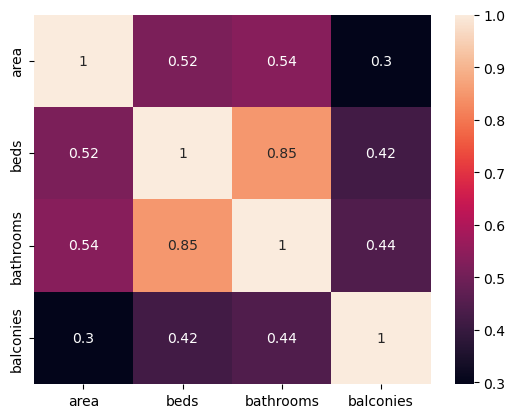

In [43]:
sns.heatmap(corr_mat,annot=True)
plt.show()

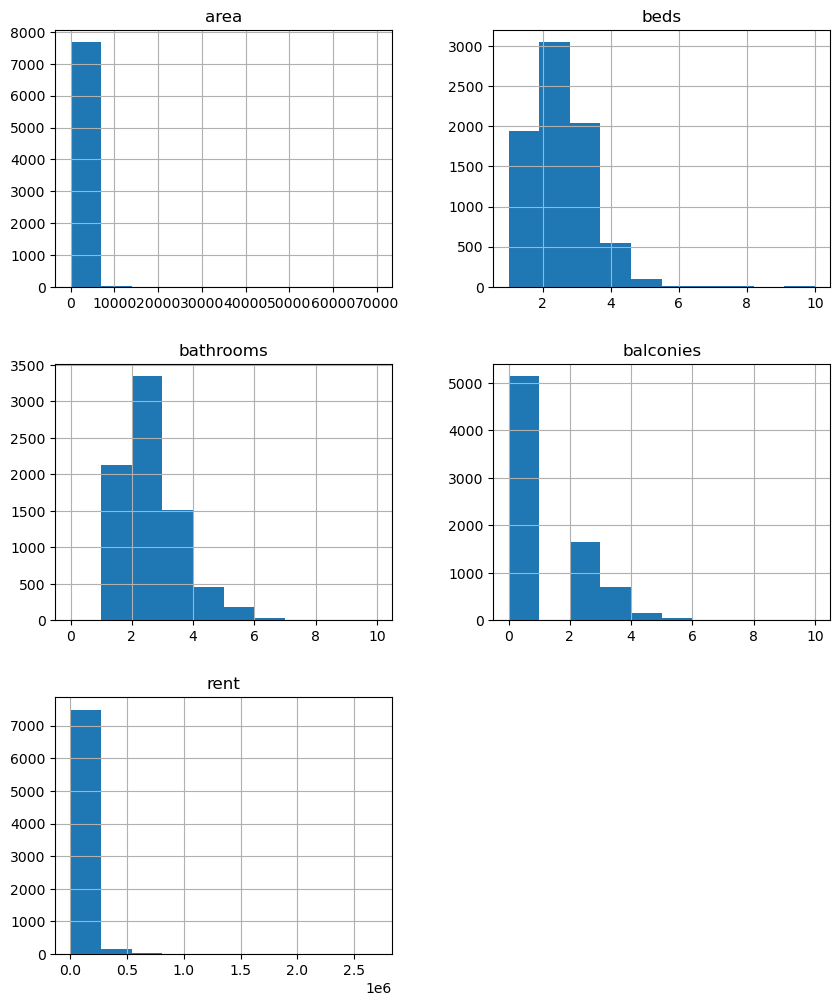

In [47]:
numerical_cols.hist(bins=10,figsize=(10,12))
plt.show()

In [48]:
df.head()

,locality,city,area,beds,bathrooms,balconies,furnishing,rent,property_type
0,Goregaon East,Mumbai,897.0,2,2,0,Semi-Furnished,120000.0,Flat
1,Powai,Mumbai,490.0,1,1,0,Semi-Furnished,40000.0,Flat
2,other,Pune,550.0,1,1,0,Unfurnished,12000.0,House
3,other,Nagpur,1000.0,2,2,0,Unfurnished,8000.0,Flat
4,Mira Road,Mumbai,595.0,1,1,0,Unfurnished,15000.0,Flat


### Saving the Cleaned file

In [49]:
df.to_csv('Rent_cleaned_data.csv',index=False)